# CMEMS Ocean-Colour products — chlorophyll, transparency, primary production

The cleanest L3 → L4 hierarchy in CMEMS lives in the GlobColour ocean-colour family. We walk the **plankton (chlorophyll)** chain from per-sensor L3 to multi-sensor L3 to gap-free L4 daily to L4 monthly, then bring in two sister themes — **transparency** (KD490, ZSD) and **primary production** (PP) — to show how the family fits together.

> **Region & window**: Gulf Stream `[-70°, -50°] × [30°, 45°]`, **2026-01-01 → 2026-01-15** (same as the SSH notebook for cross-family consistency).

Credentials live in the project-root `.env` (`COPERNICUSMARINE_SERVICE_USERNAME` / `..._PASSWORD`).

Note: Gulf Stream in mid-January is *post-bloom* and chlorophyll is on the low end of the colour scale, but the product structure is what we're after.

## 1. Setup

In [1]:
from __future__ import annotations

import warnings

import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from dotenv import load_dotenv

import copernicusmarine as cm

from xr_toolz.geo import Grid

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=RuntimeWarning)
load_dotenv()

/home/azureuser/localfiles/xr_toolz/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


True

In [2]:
BBOX = dict(
    minimum_longitude=-70.0, maximum_longitude=-50.0,
    minimum_latitude=30.0,   maximum_latitude=45.0,
)
TIME = dict(start_datetime='2026-01-01', end_datetime='2026-01-15')

# Common 0.25° reference grid for cross-product comparison.
GRID = Grid.from_bounds(
    lon_bnds=(BBOX['minimum_longitude'], BBOX['maximum_longitude']),
    lat_bnds=(BBOX['minimum_latitude'],  BBOX['maximum_latitude']),
    resolution=0.25,
)
ref = xr.Dataset(coords={'longitude': GRID.lon, 'latitude': GRID.lat})
GRID.lon.shape, GRID.lat.shape

((81,), (61,))

In [3]:
def to_common_grid(da: xr.DataArray, *, ref: xr.Dataset = ref) -> xr.DataArray:
    """Interpolate a 2D DataArray (with lat/lon coords) onto the 0.25° reference grid.

    Source resolutions in this family vary (0.05°, 0.1°, 0.25°, 4 km, 300 m); we put
    everything on a single 0.25° grid so cross-product panels share a coordinate system.
    """
    return da.interp(
        latitude=ref['latitude'],
        longitude=ref['longitude'],
        method='linear',
    )

## 2. Per-sensor L3 — multi-sensor vs OLCI alone

Two L3 streams at 4 km: the **multi-sensor merge** (OLCI + VIIRS + MODIS-Aqua, etc.) and the **OLCI Sentinel-3 single-sensor** stream binned to the same 4 km grid. CMEMS also publishes OLCI at native 300 m, but at this domain × window that product is large enough to be its own demo — left out of the cross-product comparison here.

In [4]:
L3 = {
    'multi 4 km': 'cmems_obs-oc_glo_bgc-plankton_my_l3-multi-4km_P1D',
    'OLCI 4 km':  'cmems_obs-oc_glo_bgc-plankton_my_l3-olci-4km_P1D',
}
ds_l3 = {
    label: cm.open_dataset(dataset_id=did, **BBOX, **TIME)
    for label, did in L3.items()
}
{lbl: dict(ds.sizes) for lbl, ds in ds_l3.items()}

INFO - 2026-04-28T10:55:01Z - Selected dataset version: "202603"


INFO - 2026-04-28T10:55:01Z - Selected dataset part: "default"


WARNING - 2026-04-28T10:55:01Z - The dataset cmems_obs-oc_glo_bgc-plankton_my_l3-multi-4km_P1D, version '202603', part 'default' is currently being updated. Data after 2025-10-30T00:00:00.000Z may not be up to date.


INFO - 2026-04-28T10:55:05Z - Selected dataset version: "202511"


INFO - 2026-04-28T10:55:05Z - Selected dataset part: "default"


{'multi 4 km': {'time': 15, 'latitude': 360, 'longitude': 480},
 'OLCI 4 km': {'time': 15, 'latitude': 360, 'longitude': 480}}

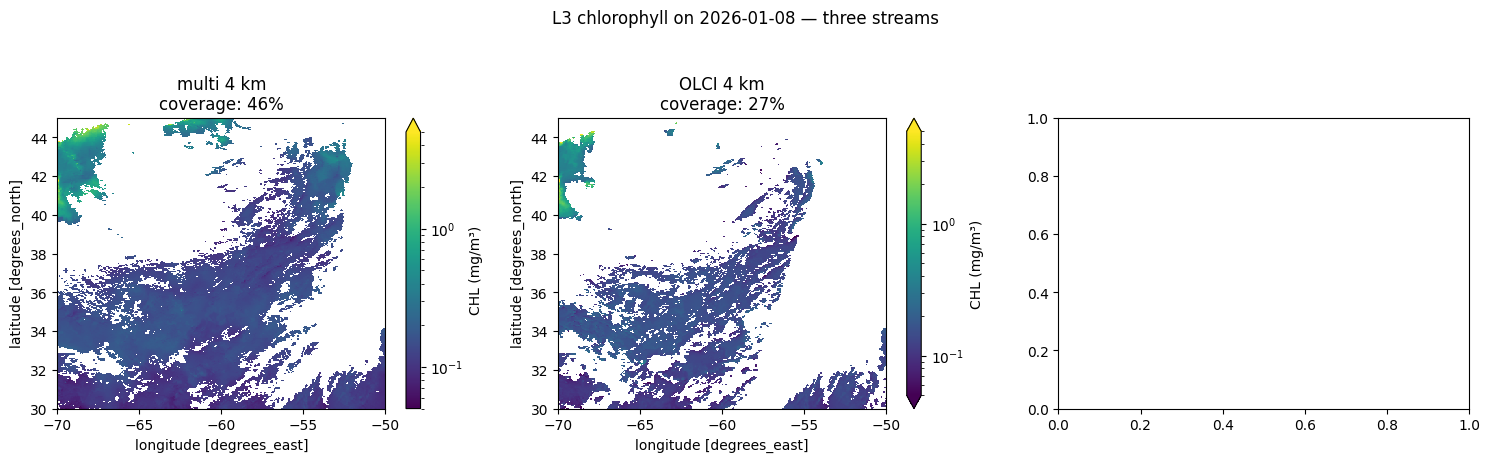

In [5]:
DAY = '2026-01-08'
import matplotlib.colors as mcolors
norm = mcolors.LogNorm(vmin=0.05, vmax=5.0)
fig, axes = plt.subplots(1, 3, figsize=(15, 4.4))
for ax, (label, ds) in zip(axes, ds_l3.items(), strict=False):
    chl = ds['CHL'].sel(time=DAY, method='nearest').squeeze()
    chl.plot.pcolormesh(ax=ax, cmap='viridis', norm=norm,
                        cbar_kwargs={'label': 'CHL (mg/m³)'})
    cov = float(np.isfinite(chl).mean())
    ax.set_title(f'{label}\ncoverage: {cov:.0%}')
fig.suptitle(f'L3 chlorophyll on {DAY} — three streams', y=1.04)
plt.tight_layout()
plt.show()

### 15-day coverage map per stream

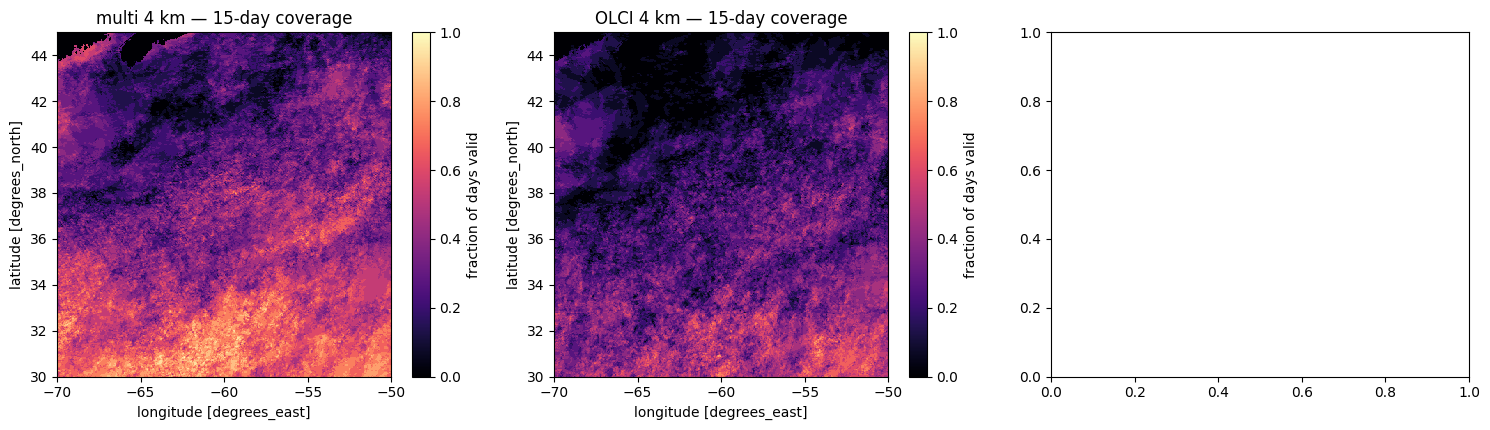

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.4))
for ax, (label, ds) in zip(axes, ds_l3.items(), strict=False):
    valid = np.isfinite(ds['CHL']).mean('time')
    valid.plot.pcolormesh(ax=ax, cmap='magma', vmin=0, vmax=1,
                          cbar_kwargs={'label': 'fraction of days valid'})
    ax.set_title(f'{label} — 15-day coverage')
plt.tight_layout()
plt.show()

## 3. L4 gap-free daily — GlobColour multi-sensor

Same multi-sensor 4 km L3 source as §2, but pushed through OI gap-filling. Output is fully populated daily.

INFO - 2026-04-28T10:55:24Z - Selected dataset version: "202603"


INFO - 2026-04-28T10:55:24Z - Selected dataset part: "default"


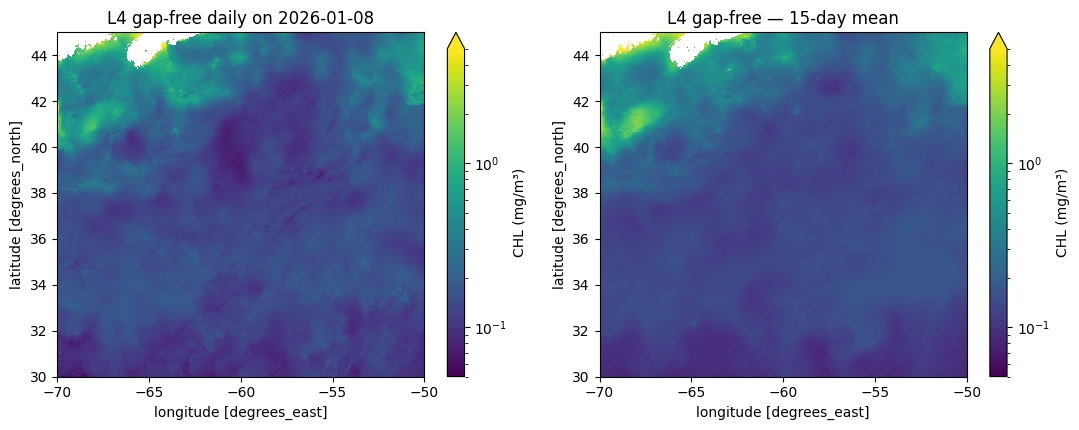

In [7]:
ds_l4_daily = cm.open_dataset(
    dataset_id='cmems_obs-oc_glo_bgc-plankton_my_l4-gapfree-multi-4km_P1D',
    **BBOX, **TIME,
)
fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
ds_l4_daily['CHL'].sel(time=DAY, method='nearest').squeeze().plot.pcolormesh(
    ax=axes[0], cmap='viridis', norm=norm,
    cbar_kwargs={'label': 'CHL (mg/m³)'},
)
axes[0].set_title(f'L4 gap-free daily on {DAY}')
ds_l4_daily['CHL'].mean('time').plot.pcolormesh(
    ax=axes[1], cmap='viridis', norm=norm,
    cbar_kwargs={'label': 'CHL (mg/m³)'},
)
axes[1].set_title('L4 gap-free — 15-day mean')
plt.tight_layout()
plt.show()

## 4. L4 monthly — multi-sensor + primary production

The native cadence for the climatologically-relevant fields. We pull the **plankton** monthly composite for January 2026, plus the sister **primary production** monthly product.

In [8]:
MONTH = dict(start_datetime='2026-01-01', end_datetime='2026-01-31')
ds_chl_m = cm.open_dataset(
    dataset_id='cmems_obs-oc_glo_bgc-plankton_my_l4-multi-4km_P1M',
    **BBOX, **MONTH,
)
ds_pp_m = cm.open_dataset(
    dataset_id='cmems_obs-oc_glo_bgc-pp_my_l4-multi-4km_P1M',
    **BBOX, **MONTH,
)
list(ds_chl_m.data_vars), list(ds_pp_m.data_vars)

INFO - 2026-04-28T10:55:34Z - Selected dataset version: "202603"


INFO - 2026-04-28T10:55:34Z - Selected dataset part: "default"


INFO - 2026-04-28T10:55:38Z - Selected dataset version: "202603"


INFO - 2026-04-28T10:55:38Z - Selected dataset part: "default"


([np.str_('CHL'),
  np.str_('CHL_uncertainty'),
  np.str_('DIATO'),
  np.str_('DIATO_uncertainty'),
  np.str_('DINO'),
  np.str_('DINO_uncertainty'),
  np.str_('GREEN'),
  np.str_('GREEN_uncertainty'),
  np.str_('HAPTO'),
  np.str_('HAPTO_uncertainty'),
  np.str_('MICRO'),
  np.str_('MICRO_uncertainty'),
  np.str_('NANO'),
  np.str_('NANO_uncertainty'),
  np.str_('PICO'),
  np.str_('PICO_uncertainty'),
  np.str_('PROCHLO'),
  np.str_('PROCHLO_uncertainty'),
  np.str_('PROKAR'),
  np.str_('PROKAR_uncertainty'),
  np.str_('flags')],
 [np.str_('PP'), np.str_('PP_uncertainty'), np.str_('flags')])

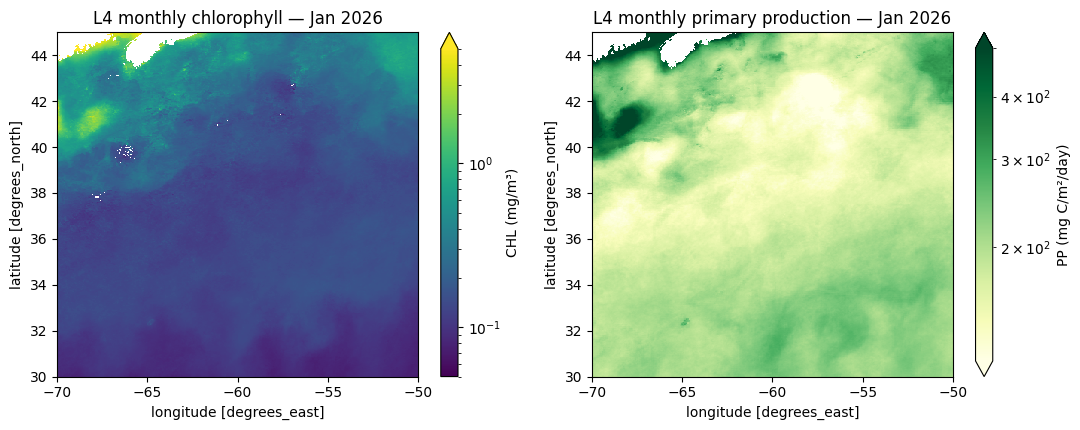

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
ds_chl_m['CHL'].squeeze().plot.pcolormesh(
    ax=axes[0], cmap='viridis', norm=norm,
    cbar_kwargs={'label': 'CHL (mg/m³)'},
)
axes[0].set_title('L4 monthly chlorophyll — Jan 2026')
pp = ds_pp_m['PP'].squeeze()
pp_norm = mcolors.LogNorm(vmin=max(float(np.nanpercentile(pp, 1)), 1.0),
                          vmax=float(np.nanpercentile(pp, 99)))
pp.plot.pcolormesh(ax=axes[1], cmap='YlGn', norm=pp_norm,
                   cbar_kwargs={'label': 'PP (mg C/m²/day)'})
axes[1].set_title('L4 monthly primary production — Jan 2026')
plt.tight_layout()
plt.show()

## 5. Sister theme — transparency (KD490, Secchi)

INFO - 2026-04-28T10:55:45Z - Selected dataset version: "202603"


INFO - 2026-04-28T10:55:45Z - Selected dataset part: "default"


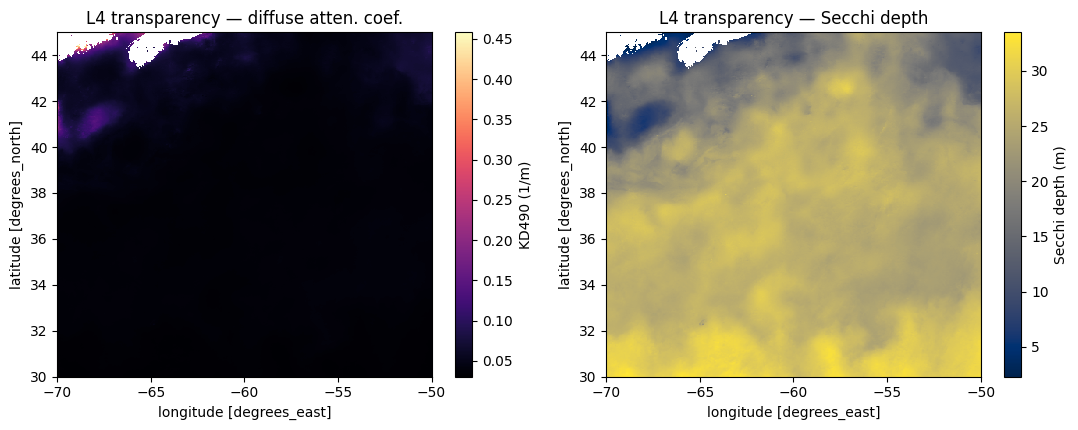

In [10]:
ds_transp = cm.open_dataset(
    dataset_id='cmems_obs-oc_glo_bgc-transp_my_l4-gapfree-multi-4km_P1D',
    **BBOX, **TIME,
)
fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
ds_transp['KD490'].mean('time').plot.pcolormesh(
    ax=axes[0], cmap='magma',
    cbar_kwargs={'label': 'KD490 (1/m)'},
)
axes[0].set_title('L4 transparency — diffuse atten. coef.')
ds_transp['ZSD'].mean('time').plot.pcolormesh(
    ax=axes[1], cmap='cividis',
    cbar_kwargs={'label': 'Secchi depth (m)'},
)
axes[1].set_title('L4 transparency — Secchi depth')
plt.tight_layout()
plt.show()

## 6. Cross-product comparison at 0.25°

Same trick as the SST and SSS notebooks: regrid each product onto the common 0.25° reference. CHL coarsens cleanly because the native 4 km grid is already gridded; we use `to_common_grid()` (linear interp) for parity with the rest of the family.

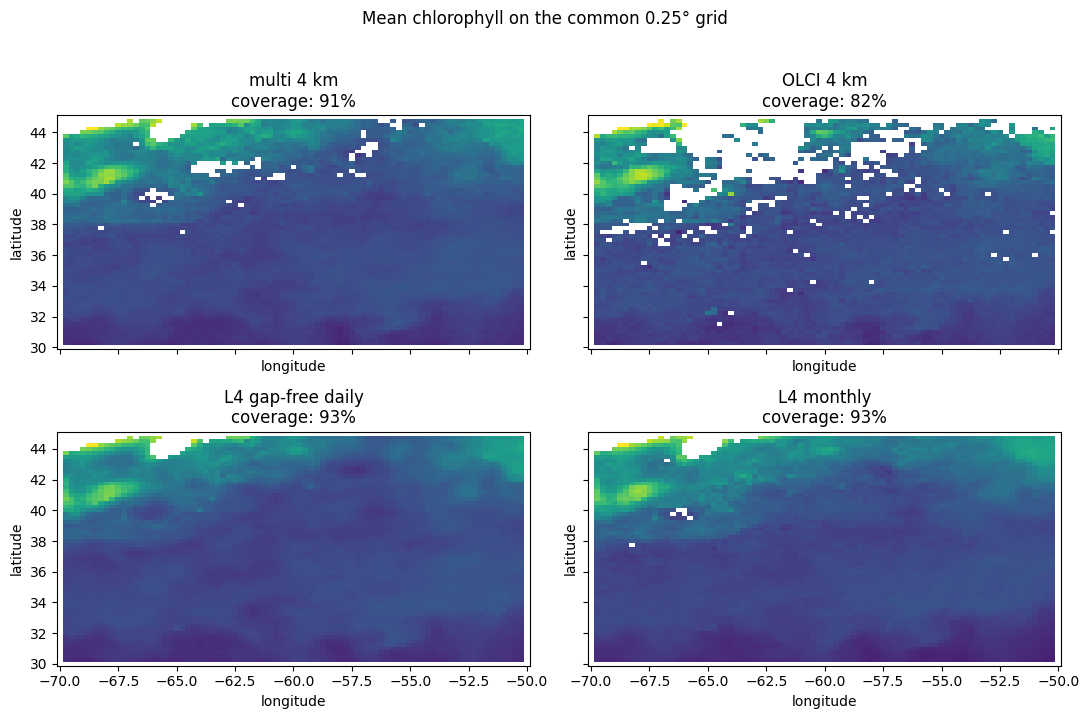

In [11]:
products_25 = {
    label: to_common_grid(ds['CHL'].mean('time'))
    for label, ds in ds_l3.items()
}
products_25['L4 gap-free daily'] = to_common_grid(ds_l4_daily['CHL'].mean('time'))
products_25['L4 monthly']        = to_common_grid(ds_chl_m['CHL'].squeeze())

fig, axes = plt.subplots(2, 2, figsize=(11, 7), sharex=True, sharey=True)
for ax, (label, da) in zip(axes.ravel(), products_25.items(), strict=False):
    da.plot.pcolormesh(ax=ax, cmap='viridis', norm=norm,
                       add_colorbar=False)
    cov = float(np.isfinite(da).mean())
    ax.set_title(f'{label}\ncoverage: {cov:.0%}')

fig.suptitle('Mean chlorophyll on the common 0.25° grid', y=1.02)
plt.tight_layout()
plt.show()

## Takeaways

- **OLCI native 300 m** is the highest-resolution OC L3 in CMEMS — useful for shelf / coastal work but heavy on data volume and cloud-gapped.
- The **multi-sensor 4 km L3** is the right entry point for most open-ocean work: still cloud-gapped, but ~2× the daily coverage of any single sensor.
- Gap-free L4 is what climatologies and primary-production calculations are built on; monthly composites smooth out the residual cloud holes definitively.
- The transparency and PP themes share the GlobColour pipeline, so switching between chlorophyll, KD490, ZSD, and PP is a matter of changing the dataset id — not the workflow.